In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.io as sio
from pathlib import Path
import seaborn as sns

# Set style for publication quality plots
plt.style.use('seaborn-v0_8-paper')
sns.set_context("paper", font_scale=1.5)

# Custom colormap function from evaluate_model.py
def colmap_hyd_py(mapsize=64, idev=1):
    iflip = 0
    if idev < 0:
        iflip = 1
        idev = abs(idev)
    
    if idev < 10:
        cmid = mapsize / 2
        np_ = int((mapsize + 1) / 5)
        top = np.ones(np_)
        bot = np.zeros(np_)
        x = np.arange(1, 2 * np_ + 2)

        if idev != 2:
            # Screen display
            wave = np.sin((x / np.max(x)) * np.pi)
            slope1 = 1.5
            slope2 = 1
        else:
            # Postscript printers
            wave = ((1 - np.cos((x / np.max(x)) * 2 * np.pi)) / 2) ** 1
            slope1 = 1
            slope2 = 2

        wave = wave[np_: 2 * np_]
        evaw = np.flip(wave)
        red = np.concatenate([
            evaw ** slope1,
            top,
            wave ** slope2,
            bot,
            bot,
            bot
        ])
        grn = np.concatenate([
            bot,
            evaw,
            top,
            top,
            wave,
            bot
        ])
        blu = np.concatenate([
            bot,
            bot,
            bot,
            evaw ** slope2,
            top,
            wave ** slope1
        ])
        colmap0 = np.vstack((red, grn, blu)).T
        mc, nc = colmap0.shape
        dif = int((mc - mapsize) / 2)
        if dif > 0:
            cmap = np.flipud(colmap0[dif: mc - dif, :])
        else:
            cmap = np.flipud(colmap0)
        
        if idev == 3:
            # Fade to black at blue end
            b1 = cmap[0, 2] * 0.9
            zbk = np.linspace(b1 / 8, b1, 8)
            z = np.zeros(8)
            cmbk = np.column_stack((z, z, zbk))
            z0 = np.zeros(4)
            cmb = np.column_stack((z0, z0, z0))
            cmap = np.vstack((cmb, cmbk, cmap))
        elif idev == 4:
            # Fade to white at blue end
            mc_cmap, nc_cmap = cmap.shape
            mm = int(0.15 * mc_cmap) + 1
            cmap = cmap[int(mm / 1.5):, :]
            sgr = np.linspace(1, 0, mm)
            b1 = cmap[0, 2]
            sb = np.linspace(1, b1, mm)
            red_channel = np.concatenate((sgr, cmap[:, 0]))
            grn_channel = np.concatenate((sgr, cmap[:, 1]))
            blu_channel = np.concatenate((sb, cmap[:, 2]))
            cmap = np.column_stack((red_channel, grn_channel, blu_channel))
        
        cmap = np.vstack((cmap, np.array([1, 1, 1])))
    
    elif idev > 9:
        # Grayscale
        maxblk = 0.2
        if idev == 10:
            grey0 = np.linspace(maxblk + (1 - maxblk) / mapsize, 1, mapsize)
            cmap = np.column_stack((grey0, grey0, grey0))
        elif idev == 11:
            nc2 = int(mapsize / 2)
            if nc2 == 0 and mapsize == 1: nc2 = 1
            
            grey1_part1 = np.linspace(maxblk + (1 - maxblk) / nc2, 1 - (1 - maxblk) / nc2, nc2) if nc2 > 0 else np.array([])
            grey1_part2 = np.linspace(1, maxblk + (1 - maxblk) / nc2, nc2) if nc2 > 0 else np.array([])
            
            if mapsize % 2 == 1 and nc2 > 0:
                if len(grey1_part1) > 0:
                    grey1_part1_adjusted = np.linspace(maxblk + (1-maxblk)/(nc2+1), 1 - (1-maxblk)/(nc2+1), nc2+1)
                    grey1_part2_adjusted = np.linspace(1, maxblk + (1-maxblk)/nc2, nc2) if nc2 > 0 else np.array([])
                    grey1 = np.concatenate((grey1_part1_adjusted, grey1_part2_adjusted))
                else:
                    grey1 = np.array([1.0])
            else:
                grey1 = np.concatenate((grey1_part1, grey1_part2))

            if len(grey1) != mapsize:
                if mapsize > 0:
                    grey1 = np.linspace(maxblk, 1, mapsize)
                else:
                    grey1 = np.array([])

            cmap = np.column_stack((grey1, grey1, grey1))
            cmap = np.vstack((cmap, np.array([1.0, 1.0, 1.0])))
    else:
        cmap = np.zeros((mapsize, 3))

    if iflip == 1:
        cmap = np.flipud(cmap)
    
    cmap = np.clip(cmap, 0, 1)
    return cmap

In [18]:
def plot_spectrogram(psd, time, freq, title=None, save_path=None, figsize=(12, 8), dpi=300):
    """
    Plot a single spectrogram with publication quality settings.
    
    Args:
        psd: 2D numpy array containing power spectral density data (freq x time)
        time: Time array
        freq: Frequency array
        title: Optional title for the plot
        save_path: Optional path to save the figure
        figsize: Figure size in inches (width, height)
        dpi: Resolution for saved figure
    """
    # Create figure
    plt.figure(figsize=figsize, dpi=dpi)
    
    # Create custom colormap
    cmap_array = colmap_hyd_py(36, 3)
    custom_cmap = mcolors.ListedColormap(cmap_array)
    
    # Convert time from MATLAB datenum to seconds from start
    time_seconds = (time - time[0]) * 24 * 3600  # Convert to seconds
    
    # Plot spectrogram
    plt.pcolormesh(time_seconds, freq, psd, cmap=custom_cmap, shading='auto')
    
    # Add colorbar
    cbar = plt.colorbar(format='%.1e')
    cbar.set_label('Power/Frequency (dB/Hz)', rotation=270, labelpad=25)
    
    # Set labels
    plt.xlabel('Time (seconds)')
    plt.ylabel('Frequency (Hz)')
    
    if title:
        plt.title(title, pad=20)
    
    # Format axes
    plt.ylim(freq[0], freq[-1])
    plt.xlim(time_seconds[0], time_seconds[-1])
    
    # Add grid
    plt.grid(False)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=dpi)
        plt.close()
    else:
        plt.show()

In [3]:
def plot_multiple_spectrograms(spec_data_list, titles=None, save_path=None, 
                             samples_per_row=2, figsize=(15, 10), dpi=300):
    """
    Plot multiple spectrograms in a grid layout.
    
    Args:
        spec_data_list: List of 2D numpy arrays containing spectrogram data
        titles: Optional list of titles for each spectrogram
        save_path: Optional path to save the figure
        samples_per_row: Number of spectrograms per row
        figsize: Base figure size in inches (width, height)
        dpi: Resolution for saved figure
    """
    n_samples = len(spec_data_list)
    n_rows = (n_samples + samples_per_row - 1) // samples_per_row
    
    # Adjust figure size based on number of spectrograms
    fig_width = figsize[0]
    fig_height = figsize[1] * (n_rows / 2)
    
    # Create custom colormap
    cmap_array = colmap_hyd_py(36, 3)
    custom_cmap = mcolors.ListedColormap(cmap_array)
    
    # Create figure
    fig = plt.figure(figsize=(fig_width, fig_height), dpi=dpi)
    
    for i, spec_data in enumerate(spec_data_list):
        plt.subplot(n_rows, samples_per_row, i + 1)
        plt.imshow(spec_data, aspect='auto', origin='lower', cmap=custom_cmap)
        
        # Add colorbar
        cbar = plt.colorbar(format='%.1e')
        cbar.set_label('Power/Frequency (dB/Hz)', rotation=270, labelpad=25)
        
        # Set labels
        plt.xlabel('Time (s)')
        plt.ylabel('Frequency (Hz)')
        
        if titles and i < len(titles):
            plt.title(titles[i], pad=10)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save or display
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=dpi)
        plt.close()
    else:
        plt.show()

In [ ]:
from pathlib import Path
import scipy
import os

# Example loading and plotting a single .mat file
base_path = Path("/mnt/z/CIOOS_Anomaly_detection_work/Several Locations - Anomalies Folder/tonals/27kHz/mat")

# List all .mat files in the directory
mat_files = list(Path(base_path).glob("*.mat"))

# Load and inspect the data structure
mat_path = mat_files[0]  # Get first .mat file
EXPECTED_SHAPE = (854, 1000)

try:
    mat_data = sio.loadmat(mat_path)
except (scipy.io.matlab._miobase.MatReadError, ValueError) as e:
    print(f"Skipping empty or invalid MAT file: {os.path.basename(mat_path)}")
    raise
except Exception as e:
    print(f"Unexpected error processing {os.path.basename(mat_path)}: {str(e)}")
    raise

if 'SpectData' in mat_data:
    spect_struct = mat_data['SpectData'][0, 0]
    # Get the data - using the correct method to reshape the PSD
    psd = np.array(spect_struct['PSD'].tolist()).squeeze()  # Shape (854, 1000)
    
    # Check if spectrogram is shortened
    if psd.shape[1] < EXPECTED_SHAPE[1]:
        print(f"{os.path.basename(mat_path)} has shape {psd.shape}, padding to {EXPECTED_SHAPE}")
        padding_width = ((0, 0), (0, EXPECTED_SHAPE[1] - psd.shape[1]))
        psd = np.pad(psd, padding_width, mode='constant', constant_values=0)
    
    time = spect_struct['time'][0]  # Shape (1000,)
    freq = spect_struct['frequency'].flatten() / 1000  # Convert to kHz

    # Handle invalid values
    psd[psd == -np.inf] = 0
    psd = np.nan_to_num(psd, nan=0.0)

    def plot_spectrogram(psd, time, freq, save_path=None, figsize=(12, 12), dpi=300):
        """
        Plot a single spectrogram with publication quality settings.
        """
        # Set font sizes
        plt.rcParams.update({
            'font.size': 16,
            'axes.labelsize': 18,
            'axes.titlesize': 18,
            'xtick.labelsize': 16,
            'ytick.labelsize': 16,
            'legend.fontsize': 16,
        })
        
        # Create figure with transparent background
        fig = plt.figure(figsize=figsize, dpi=dpi)
        fig.patch.set_alpha(0)  # Make figure background transparent
        
        # Create main axes with specific position to make room for colorbar
        ax = plt.axes([0.15, 0.15, 0.65, 0.75])  # [left, bottom, width, height]
        ax.patch.set_alpha(0)  # Make plot background transparent
        
        # Create custom colormap
        cmap_array = colmap_hyd_py(36, 3)
        custom_cmap = mcolors.ListedColormap(cmap_array)
        
        # Convert time from MATLAB datenum to seconds from start
        time_seconds = (time - time[0]) * 24 * 3600  # Convert to seconds
        
        # Plot spectrogram using imshow with specific value range
        im = ax.imshow(psd, 
                    extent=[time_seconds[0], time_seconds[-1], freq[0], freq[-1]],
                    aspect='auto',  # Let imshow calculate the correct aspect ratio
                    origin='lower',
                    cmap=custom_cmap,
                    vmin=40,  # Set minimum value
                    vmax=140)  # Set maximum value
        
        # Force the aspect ratio to be square
        ax.set_aspect(abs((time_seconds[-1]-time_seconds[0])/(freq[-1]-freq[0])))
        
        # Add colorbar with specific ticks and adjusted position to match spectrogram height
        cax = plt.axes([0.85, 0.20, 0.03, 0.51])  # Reduced height to match spectrogram
        cbar = plt.colorbar(im, cax=cax, ticks=np.arange(40, 141, 10))
        
        # Remove existing colorbar label
        cbar.set_label('')
        
        # Add title above colorbar but within the figure bounds
        title_ax = plt.axes([0.82, 0.74, 0.1, 0.1])  # Adjusted position for title
        title_ax.axis('off')
        title_ax.text(0.5, 0.5, 'Power\nSpectral\nDensity (dB\nre 1 μPa²/Hz)',
                     horizontalalignment='center',
                     verticalalignment='center',
                     fontsize=18,
                     linespacing=1.5)
        
        cbar.ax.tick_params(labelsize=16)
        
        # Set labels on main plot
        ax.set_xlabel('Time (seconds)', fontsize=18, labelpad=10)
        ax.set_ylabel('Frequency (kHz)', fontsize=18, labelpad=10)
        
        # Format frequency axis with integer ticks
        yticks = np.linspace(freq[0], freq[-1], 8)
        ax.set_yticks(yticks)
        ax.set_yticklabels([f'{int(y)}' for y in yticks])
        
        if save_path:
            plt.savefig(save_path, bbox_inches='tight', dpi=dpi, transparent=True)
            plt.close()
        else:
            plt.show()

    # Plot the spectrogram
    plot_spectrogram(
        psd,
        time,
        freq,
        figsize=(12, 12),
        save_path='../figures/spectrogram_rain.png'
)

JASCOAMARHYDROPHONE2402_20161004T235803.165Z_20161005T000302.865Z-OD-spect_plotRes.mat has shape (854, 999), padding to (854, 1000)


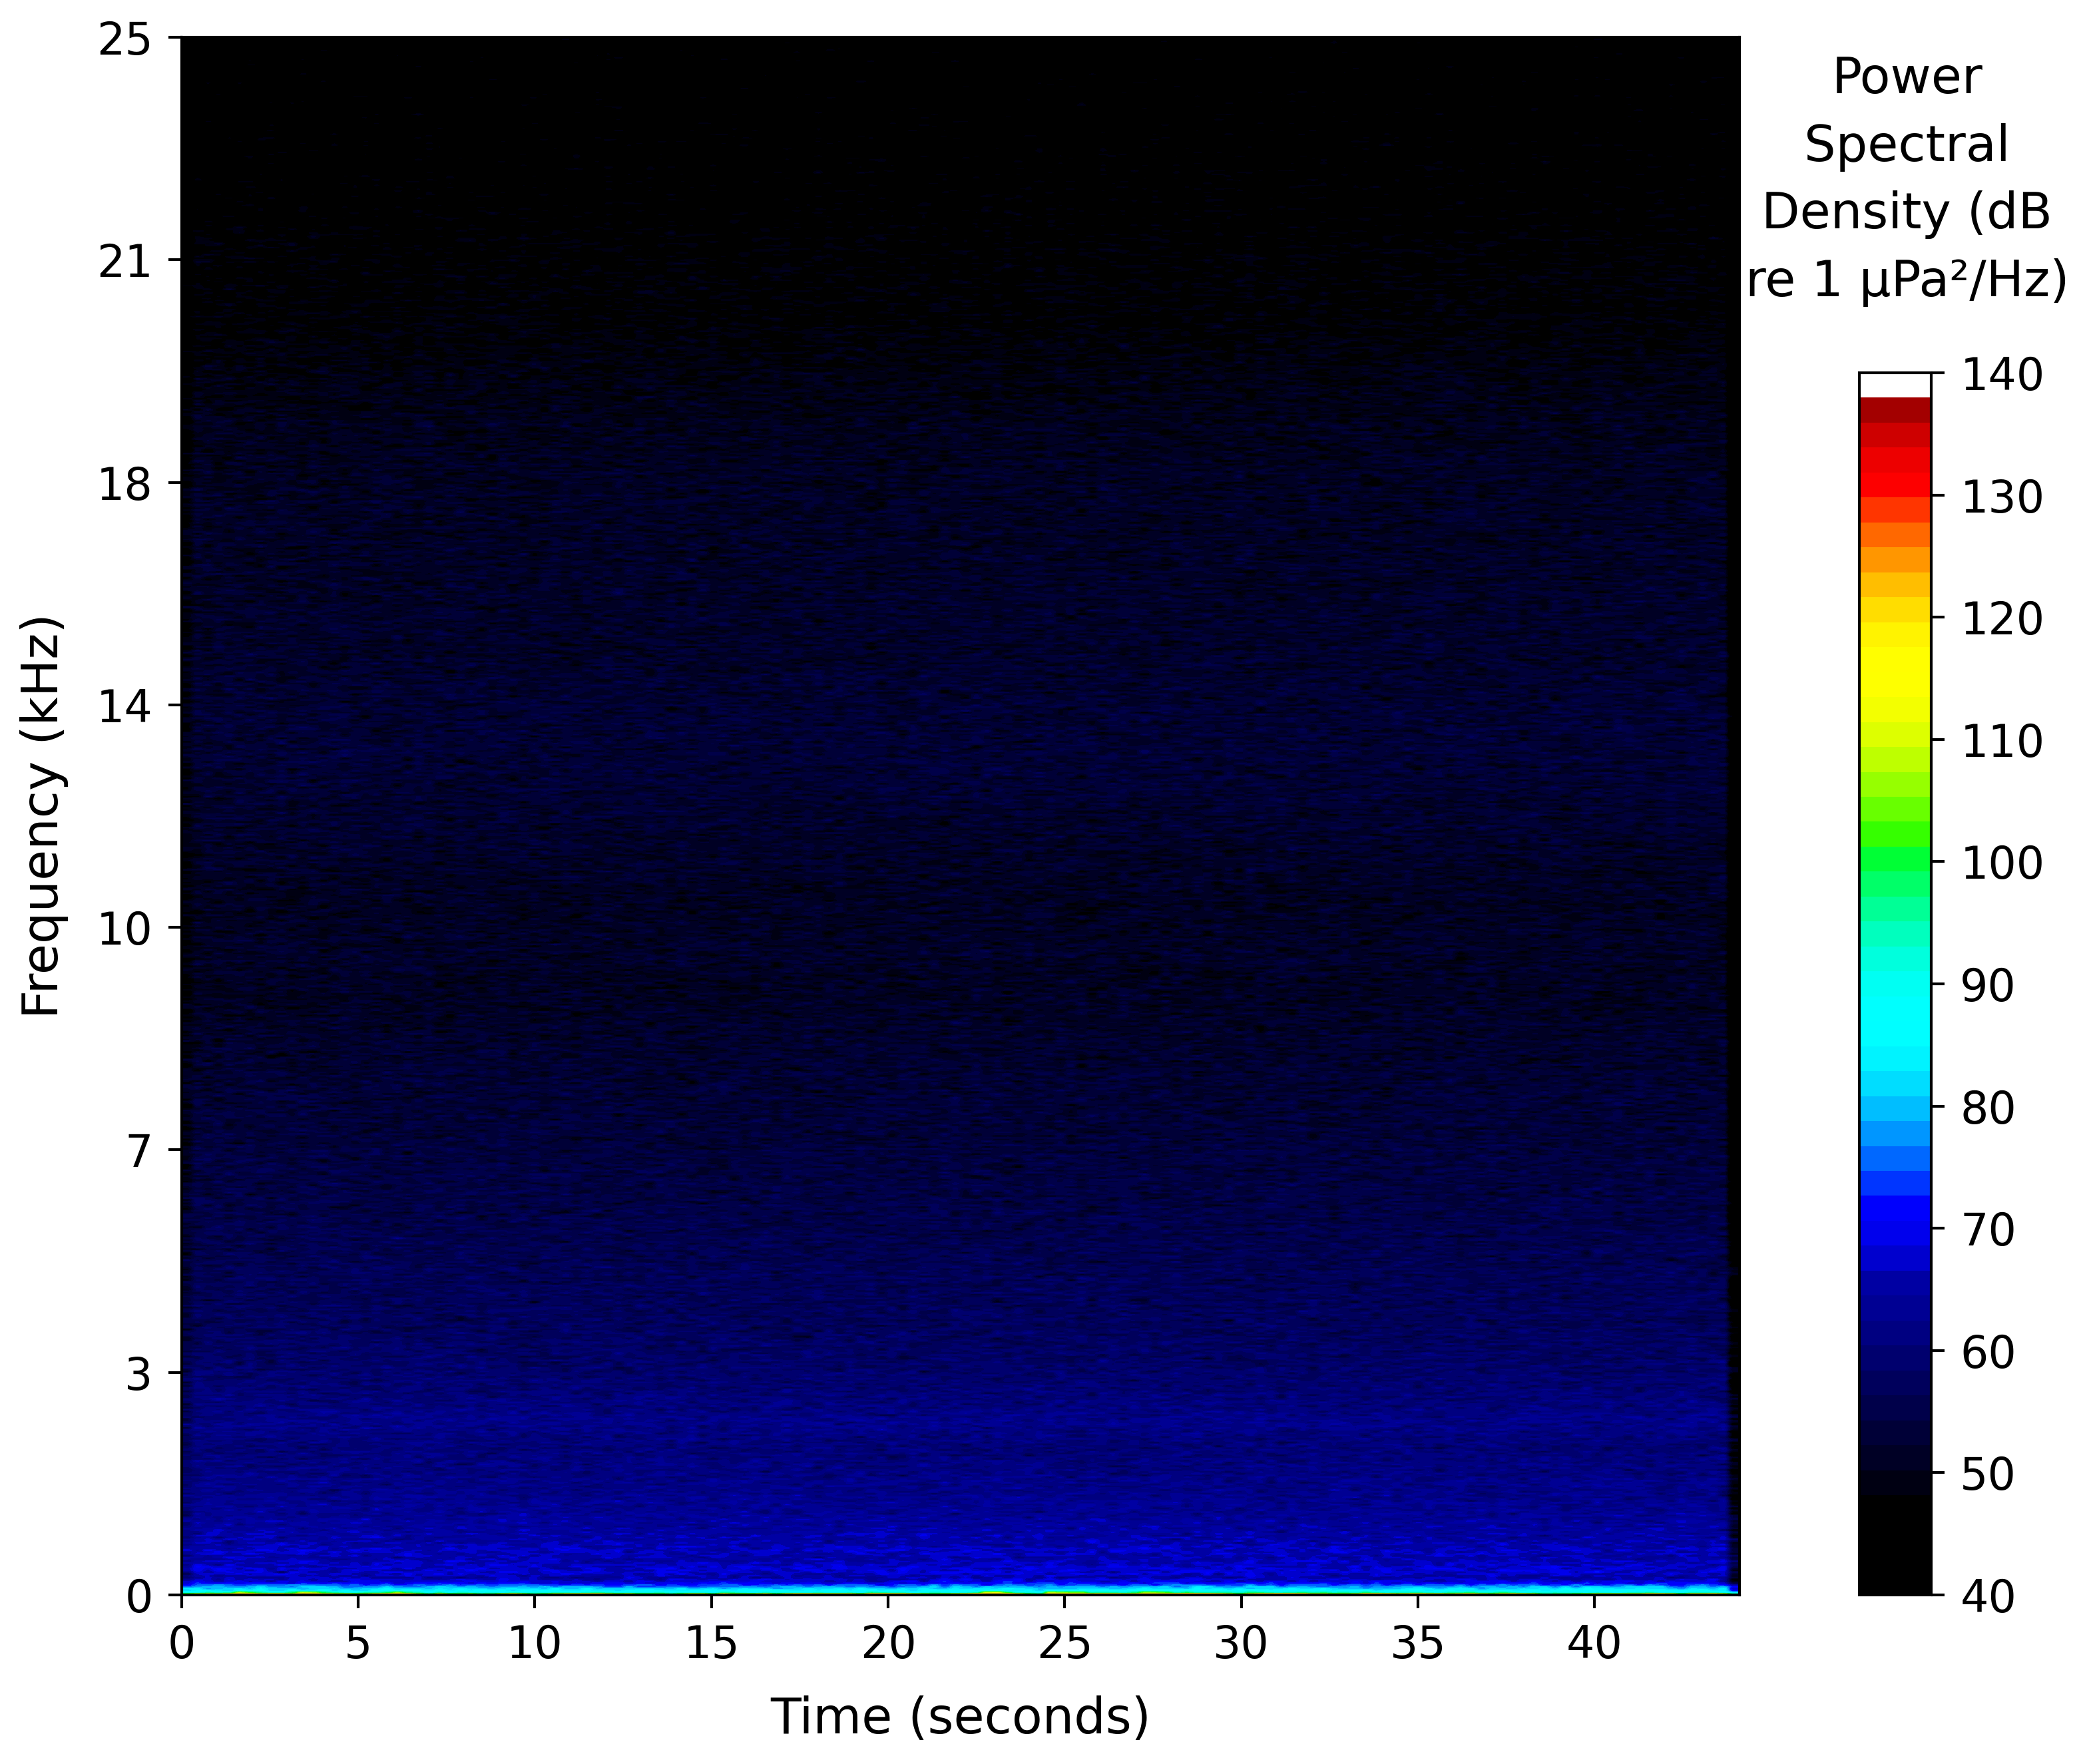

In [67]:
# Load and inspect the data structure
mat_path = mat_files[0]  # Get first .mat file
mat_data = sio.loadmat(mat_path)
spect_struct = mat_data['SpectData'][0, 0]

# Get the data - using the correct method to reshape the PSD
psd = np.array(spect_struct['PSD'].tolist()).squeeze()  # Shape (854, 1000)
time = spect_struct['time'][0]  # Shape (1000,)
freq = spect_struct['frequency'].flatten() / 1000  # Convert to kHz

# Handle invalid values
psd[psd == -np.inf] = 0
psd = np.nan_to_num(psd, nan=0.0)

def plot_spectrogram(psd, time, freq, save_path=None, figsize=(12, 12), dpi=300):
    """
    Plot a single spectrogram with publication quality settings.
    """
    # Set font sizes
    plt.rcParams.update({
        'font.size': 16,
        'axes.labelsize': 18,
        'axes.titlesize': 18,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 16,
    })
    
    # Create figure with transparent background
    fig = plt.figure(figsize=figsize, dpi=dpi)
    fig.patch.set_alpha(0)  # Make figure background transparent
    
    # Create main axes with specific position to make room for colorbar
    ax = plt.axes([0.15, 0.15, 0.65, 0.75])  # [left, bottom, width, height]
    ax.patch.set_alpha(0)  # Make plot background transparent
    
    # Create custom colormap
    cmap_array = colmap_hyd_py(36, 3)
    custom_cmap = mcolors.ListedColormap(cmap_array)
    
    # Convert time from MATLAB datenum to seconds from start
    time_seconds = (time - time[0]) * 24 * 3600  # Convert to seconds
    
    # Plot spectrogram using imshow with specific value range
    im = ax.imshow(psd, 
                   extent=[time_seconds[0], time_seconds[-1], freq[0], freq[-1]],
                   aspect='auto',  # Let imshow calculate the correct aspect ratio
                   origin='lower',
                   cmap=custom_cmap,
                   vmin=40,  # Set minimum value
                   vmax=140)  # Set maximum value
    
    # Force the aspect ratio to be square
    ax.set_aspect(abs((time_seconds[-1]-time_seconds[0])/(freq[-1]-freq[0])))
    
    # Add colorbar with specific ticks and adjusted position to match spectrogram height
    cax = plt.axes([0.85, 0.20, 0.03, 0.51])  # Reduced height to match spectrogram
    cbar = plt.colorbar(im, cax=cax, ticks=np.arange(40, 141, 10))
    
    # Remove existing colorbar label
    cbar.set_label('')
    
    # Add title above colorbar but within the figure bounds
    title_ax = plt.axes([0.82, 0.74, 0.1, 0.1])  # Adjusted position for title
    title_ax.axis('off')
    title_ax.text(0.5, 0.5, 'Power\nSpectral\nDensity (dB\nre 1 μPa²/Hz)',
                 horizontalalignment='center',
                 verticalalignment='center',
                 fontsize=18,
                 linespacing=1.5)
    
    cbar.ax.tick_params(labelsize=16)
    
    # Set labels on main plot
    ax.set_xlabel('Time (seconds)', fontsize=18, labelpad=10)
    ax.set_ylabel('Frequency (kHz)', fontsize=18, labelpad=10)
    
    # Format frequency axis with integer ticks
    yticks = np.linspace(freq[0], freq[-1], 8)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{int(y)}' for y in yticks])
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=dpi, transparent=True)
        plt.close()
    else:
        plt.show()

# Plot the spectrogram
plot_spectrogram(
    psd,
    time,
    freq,
    figsize=(12, 12)
)

Found 10 files with label 'Anomaly'
Randomly sampling 10 files


/tmp/ipykernel_31444/1400409431.py:52: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  selected_files = dict(random.sample(matching_files.items(), num_samples))
/tmp/ipykernel_31444/1400409431.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make room for colorbar


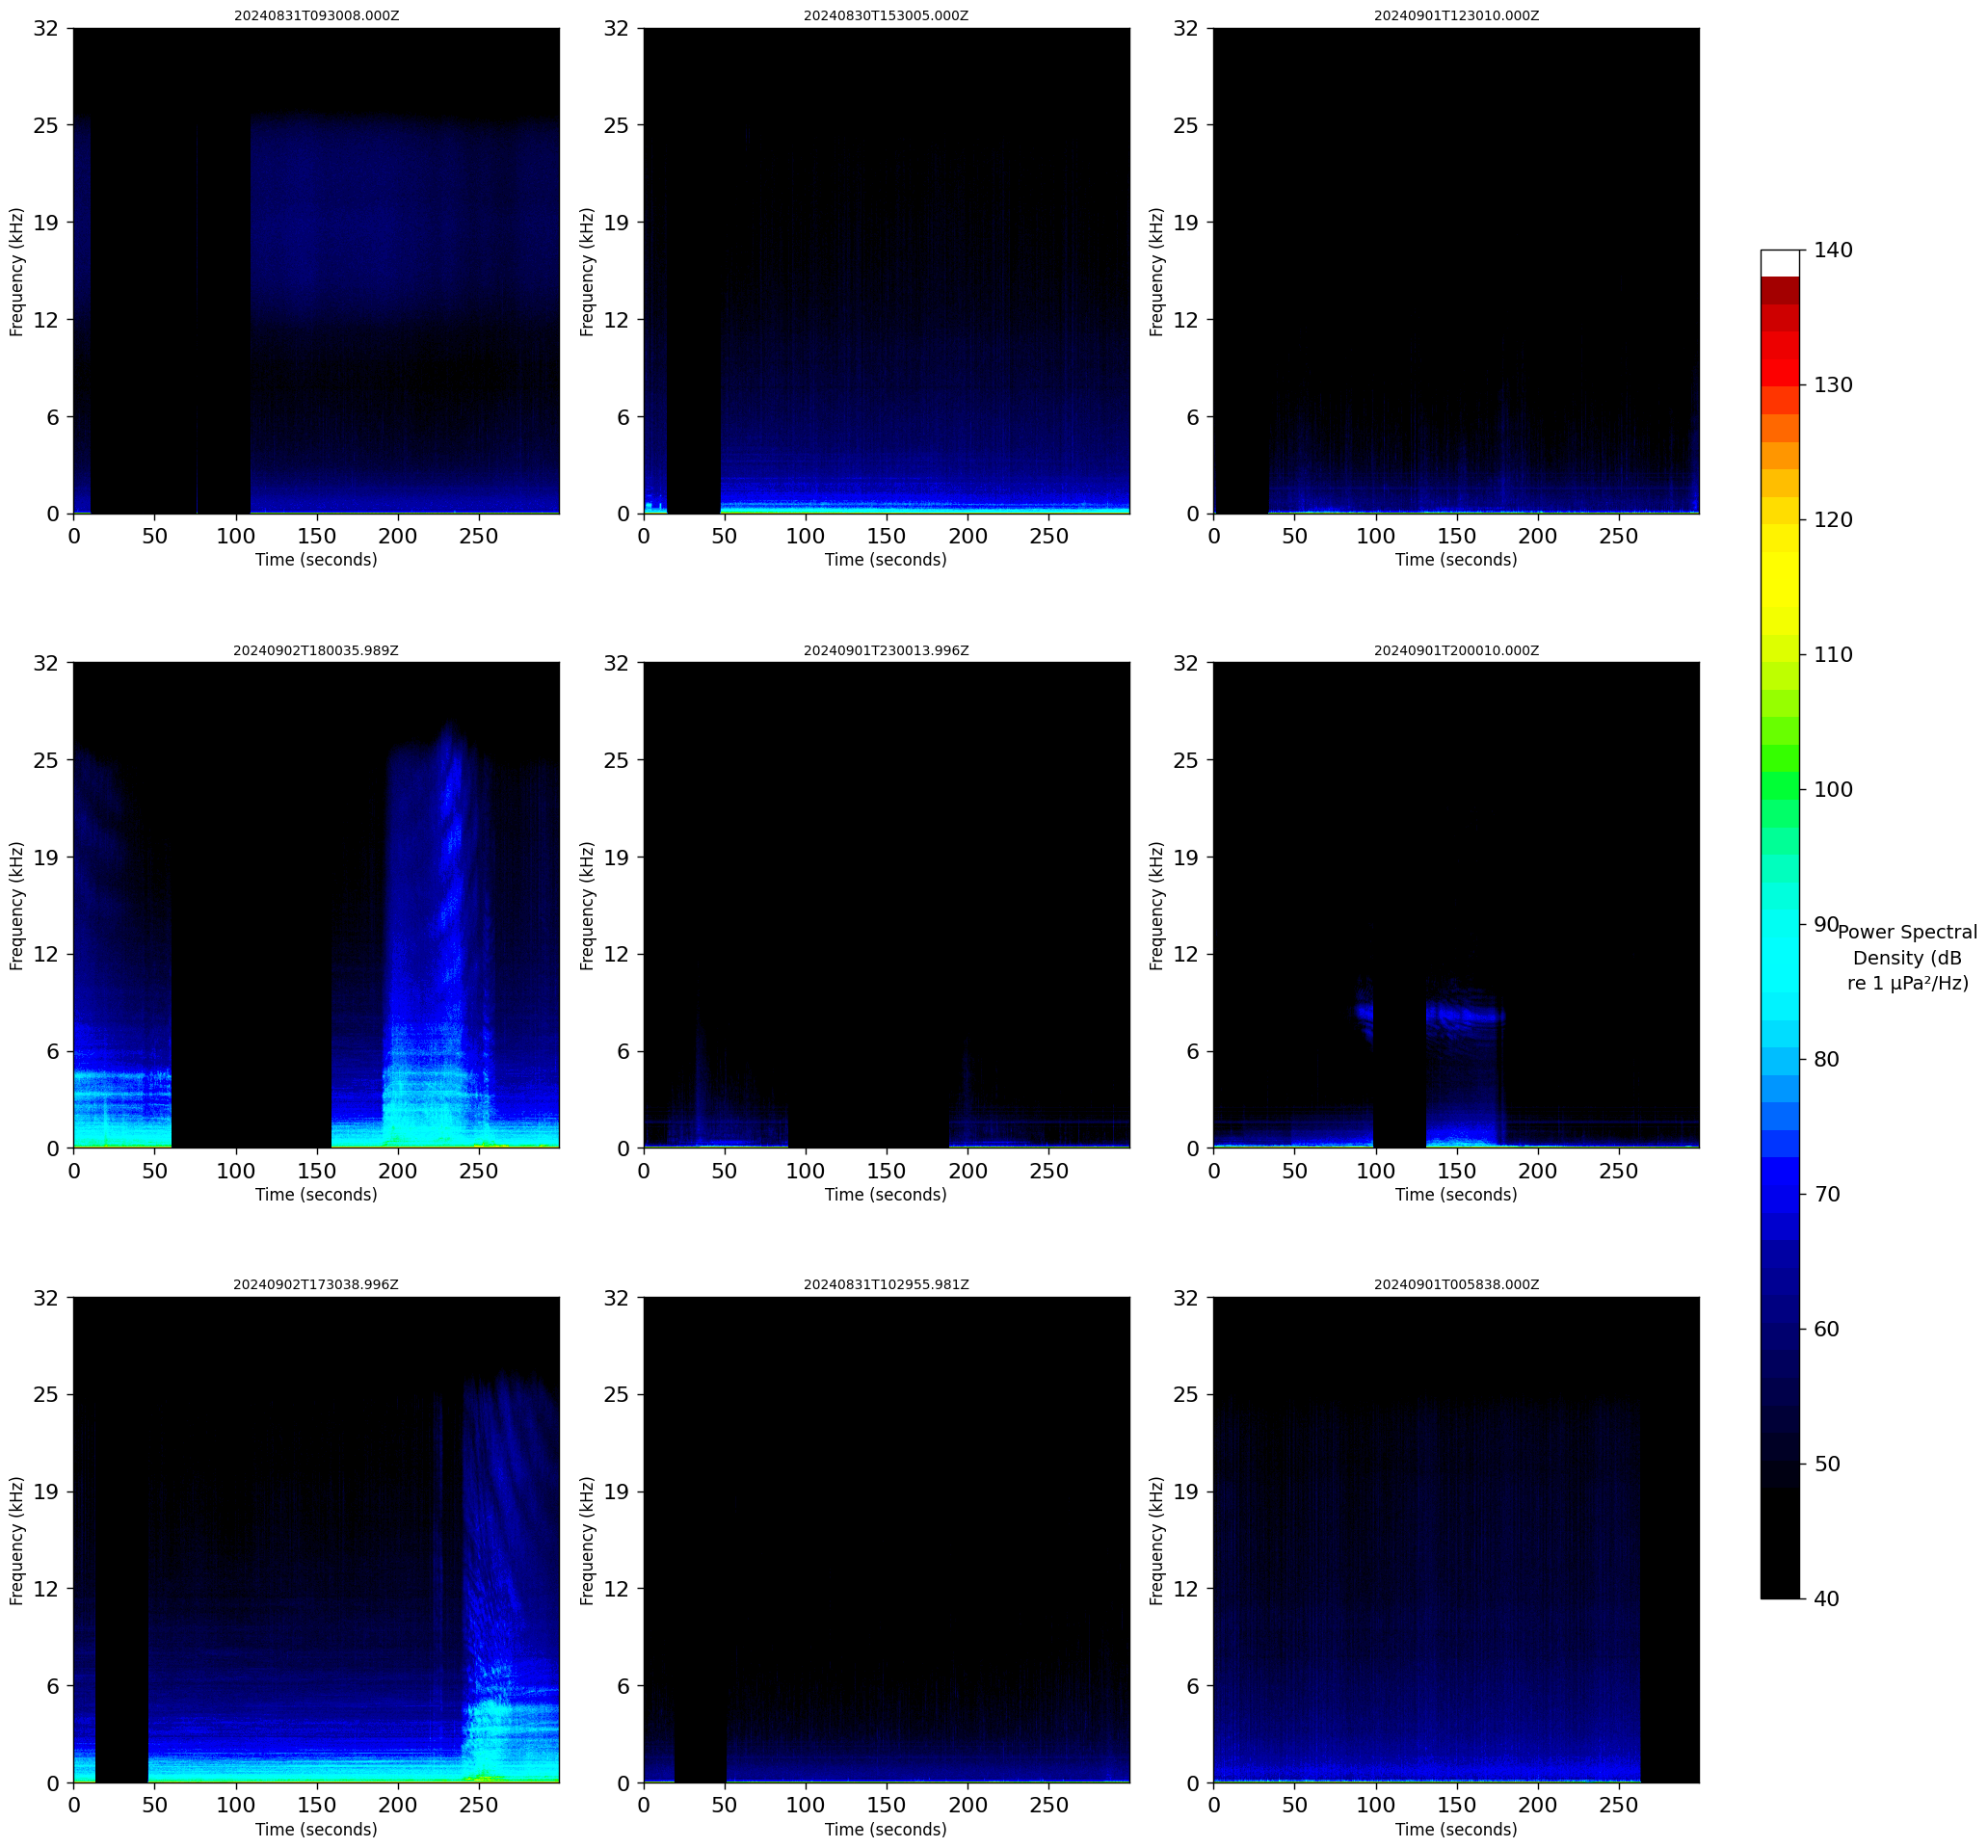

In [96]:
import json
import os
from pathlib import Path
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
import random

def load_and_filter_spectrograms(base_folder, target_label, num_samples=None, random_seed=None):
    """
    Load spectrograms from a base folder that match a specific label.
    
    Parameters
    ----------
    base_folder : str
        Path to the base folder containing labels.json and matfiles folder
    target_label : str
        The label to filter for (case-sensitive)
    num_samples : int, optional
        Number of spectrograms to load. If None, loads all matching spectrograms.
        If specified, randomly samples this many spectrograms from matching files.
    random_seed : int, optional
        Random seed for reproducible sampling. Only used if num_samples is specified.
        
    Returns
    -------
    dict
        Dictionary with filenames as keys and tuples of (psd, time, freq) as values
    """
    base_path = Path(base_folder)
    json_path = base_path / 'labels.json'
    matfiles_path = base_path / 'matfiles'
    
    # Load labels
    with open(json_path, 'r') as f:
        labels_dict = json.load(f)
    
    # Filter files with target label
    matching_files = {filename: labels for filename, labels in labels_dict.items() 
                     if target_label in labels}
    
    print(f"Found {len(matching_files)} files with label '{target_label}'")
    
    # If num_samples specified, randomly sample from matching files
    if num_samples is not None:
        if random_seed is not None:
            random.seed(random_seed)
        
        # Ensure we don't try to sample more than we have
        num_samples = min(num_samples, len(matching_files))
        selected_files = dict(random.sample(matching_files.items(), num_samples))
        print(f"Randomly sampling {num_samples} files")
    else:
        selected_files = matching_files
    
    # Load matching spectrograms
    EXPECTED_SHAPE = (854, 1000)
    spectrograms = {}
    
    for filename in selected_files.keys():
        mat_path = matfiles_path / filename
        
        try:
            mat_data = sio.loadmat(mat_path)
            
            if 'SpectData' in mat_data:
                spect_struct = mat_data['SpectData'][0, 0]
                psd = np.array(spect_struct['PSD'].tolist()).squeeze()
                
                # Check if spectrogram is shortened
                if psd.shape[1] < EXPECTED_SHAPE[1]:
                    print(f"{filename} has shape {psd.shape}, padding to {EXPECTED_SHAPE}")
                    padding_width = ((0, 0), (0, EXPECTED_SHAPE[1] - psd.shape[1]))
                    psd = np.pad(psd, padding_width, mode='constant', constant_values=0)
                
                # Handle invalid values
                psd[psd == -np.inf] = 0
                psd = np.nan_to_num(psd, nan=0.0)
                
                time = spect_struct['time'][0]
                freq = spect_struct['frequency'].flatten() / 1000  # Convert to kHz
                
                spectrograms[filename] = (psd, time, freq)
            
        except Exception as e:
            print(f"Error processing {filename}: {str(e)}")
            continue
    
    return spectrograms

def plot_filtered_spectrograms(spectrograms, rows=2, cols=2, figsize=(20, 20)):
    """
    Plot a grid of spectrograms.
    
    Parameters
    ----------
    spectrograms : dict
        Dictionary of spectrograms from load_and_filter_spectrograms
    rows, cols : int
        Number of rows and columns in the grid
    figsize : tuple
        Figure size
    """
    # Calculate how many spectrograms we can actually plot
    max_plots = rows * cols
    spec_items = list(spectrograms.items())[:max_plots]
    actual_plots = len(spec_items)
    
    if actual_plots < max_plots:
        print(f"Warning: Only {actual_plots} spectrograms available for {max_plots} plot spaces")
    
    fig = plt.figure(figsize=figsize)
    fig.patch.set_alpha(0)  # Transparent background
    
    for idx, (filename, (psd, time, freq)) in enumerate(spec_items):
        # Create subplot
        ax = plt.subplot(rows, cols, idx + 1)
        ax.patch.set_alpha(0)  # Transparent background
        
        # Create custom colormap
        cmap_array = colmap_hyd_py(36, 3)
        custom_cmap = mcolors.ListedColormap(cmap_array)
        
        # Convert time to seconds from start
        time_seconds = (time - time[0]) * 24 * 3600
        
        # Plot spectrogram
        im = ax.imshow(psd,
                      extent=[time_seconds[0], time_seconds[-1], freq[0], freq[-1]],
                      aspect='auto',
                      origin='lower',
                      cmap=custom_cmap,
                      vmin=40,
                      vmax=140)
        
        # Force square aspect ratio
        ax.set_aspect(abs((time_seconds[-1]-time_seconds[0])/(freq[-1]-freq[0])))
        
        # Labels
        ax.set_xlabel('Time (seconds)', fontsize=12)
        ax.set_ylabel('Frequency (kHz)', fontsize=12)
        
        # Title (shortened filename)
        short_name = filename.split('_')[1]  # Get the timestamp part
        ax.set_title(short_name, fontsize=10)
        
        # Integer ticks for frequency
        yticks = np.linspace(freq[0], freq[-1], 6)
        ax.set_yticks(yticks)
        ax.set_yticklabels([f'{int(y)}' for y in yticks])
    
    # Add colorbar to the right of the subplots
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax, ticks=np.arange(40, 141, 10))
    cbar.set_label('Power Spectral\nDensity (dB\nre 1 μPa²/Hz)', 
                   rotation=0,
                   labelpad=40,
                   size=14,
                   linespacing=1.5)
    
    plt.tight_layout(rect=[0, 0, 0.9, 1])  # Adjust layout to make room for colorbar
    plt.show()

# Example usage:
base_folder = Path("/mnt/z/CIOOS_Anomaly_detection_work/CambridgeBay")  # Replace with your folder path
target_label = "Anomaly"  # Or "Dropout" or any other label

# Load a random subset of 4 spectrograms with the target label
spectrograms = load_and_filter_spectrograms(
    base_folder, 
    target_label,
    num_samples=20,  # Get 4 random spectrograms
    random_seed=42  # For reproducibility
)

# Plot the spectrograms in a 2x2 grid
if spectrograms:
    plot_filtered_spectrograms(spectrograms, rows=3, cols=3)
else:
    print(f"No spectrograms found with label '{target_label}'")


In [93]:
def plot_single_spectrogram(spectrogram_tuple, title=None, figsize=(12, 12), dpi=300, save_path=None):
    """
    Plot a single spectrogram with publication quality settings.
    
    Parameters
    ----------
    spectrogram_tuple : tuple
        Tuple containing (psd, time, freq) from the spectrograms dictionary
    title : str, optional
        Title for the plot. If None, no title is shown.
    figsize : tuple, optional
        Figure size in inches (width, height)
    dpi : int, optional
        Resolution for the figure
    """
    psd, time, freq = spectrogram_tuple
    
    # Set font sizes
    plt.rcParams.update({
        'font.size': 16,
        'axes.labelsize': 18,
        'axes.titlesize': 18,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 16,
    })
    
    # Create figure with transparent background
    fig = plt.figure(figsize=figsize, dpi=dpi)
    fig.patch.set_alpha(0)  # Make figure background transparent
    
    # Create main axes with specific position to make room for colorbar
    ax = plt.axes([0.15, 0.15, 0.65, 0.75])  # [left, bottom, width, height]
    ax.patch.set_alpha(0)  # Make plot background transparent
    
    # Create custom colormap
    cmap_array = colmap_hyd_py(36, 3)
    custom_cmap = mcolors.ListedColormap(cmap_array)
    
    # Convert time from MATLAB datenum to seconds from start
    time_seconds = (time - time[0]) * 24 * 3600  # Convert to seconds
    
    # Plot spectrogram using imshow with specific value range
    im = ax.imshow(psd, 
                   extent=[time_seconds[0], time_seconds[-1], freq[0], freq[-1]],
                   aspect='auto',  # Let imshow calculate the correct aspect ratio
                   origin='lower',
                   cmap=custom_cmap,
                   vmin=40,  # Set minimum value
                   vmax=140)  # Set maximum value
    
    # Force the aspect ratio to be square
    ax.set_aspect(abs((time_seconds[-1]-time_seconds[0])/(freq[-1]-freq[0])))
    
    # Add colorbar with specific ticks and adjusted position to match spectrogram height
    cax = plt.axes([0.85, 0.20, 0.03, 0.51])  # Reduced height to match spectrogram
    cbar = plt.colorbar(im, cax=cax, ticks=np.arange(40, 141, 10))
    
    # Remove existing colorbar label
    cbar.set_label('')
    
    # Add title above colorbar but within the figure bounds
    title_ax = plt.axes([0.82, 0.74, 0.1, 0.1])  # Adjusted position for title
    title_ax.axis('off')
    title_ax.text(0.5, 0.5, 'Power\nSpectral\nDensity (dB\nre 1 μPa²/Hz)',
                 horizontalalignment='center',
                 verticalalignment='center',
                 fontsize=18,
                 linespacing=1.5)
    
    cbar.ax.tick_params(labelsize=16)
    
    # Set labels on main plot
    ax.set_xlabel('Time (seconds)', fontsize=18, labelpad=10)
    ax.set_ylabel('Frequency (kHz)', fontsize=18, labelpad=10)
    
    # Format frequency axis with integer ticks
    yticks = np.linspace(freq[0], freq[-1], 8)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f'{int(y)}' for y in yticks])
    
    # Add title if provided
    if title:
        ax.set_title(title, pad=20, fontsize=18)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=dpi, transparent=True)
        plt.close()
    else:
        plt.show()
    
    plt.show()

In [94]:
if spectrograms:
    # Get the first (and only) spectrogram
    filename, spec_tuple = next(iter(spectrograms.items()))
    
    # Plot it with the timestamp as the title
    timestamp = filename.split('_')[1]
    plot_single_spectrogram(spec_tuple, save_path='../figures/spectrogram_rain.png')

else:
    print(f"No spectrograms found with label '{target_label}'")
